# **3. Exploratory Data Analysis (EDA)**

> This notebook answers the question: **"What does this data tell?"**
> The analysis is conducted systematically, from an overview of the dataset,
> segment profiles, churn behavior, to the relationships between variables.

**Input:**  `data/raw/rewards_synthetic.csv`

**Output:** 10 visualisasi tersimpan di `outputs/figures/`

## 📦 0. Setup & Load Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, warnings
from datetime import datetime

warnings.filterwarnings("ignore")
np.random.seed(42)

os.makedirs("../outputs/figures", exist_ok=True)

# Styling global
plt.rcParams.update({
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : False,
    "font.size"         : 10,
})

COLORS = {
    "Champions" : "#2ECC71",
    "Loyal"     : "#3498DB",
    "At_Risk"   : "#E67E22",
    "Promising" : "#9B59B6",
    "Hibernating": "#95A5A6",
}
SEG_ORDER  = ["Champions", "Loyal", "At_Risk", "Promising", "Hibernating"]
TIER_ORDER = ["Platinum", "Gold", "Silver", "Member"]

df = pd.read_csv("../data/raw/rewards_synthetic.csv")
df["last_tx_date"] = pd.to_datetime(df["last_tx_date"])

print(f"✓ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"  Kolom: {df.columns.tolist()}")
print(f"  Churn rate: {df['churn_label'].mean():.1%}")

✓ Dataset loaded: 10,000 rows × 12 cols
  Kolom: ['user_id', 'segment_true', 'last_tx_date', 'recency_days', 'frequency_monthly', 'monetary_monthly', 'ovo_points_balance', 'tier', 'services_used', 'n_services', 'city', 'churn_label']
  Churn rate: 34.4%


## **1. Overview Dataset**

Understanding **data form and quality**: how much data, the type of each column, whether there are missing values, and what the underlying distribution is.

In [3]:
print("=" * 60)
print("  GAMBARAN UMUM DATASET")
print("=" * 60)
print(f"\n  Jumlah pengguna  : {len(df):,}")
print(f"  Jumlah kolom     : {df.shape[1]}")
print(f"  Duplikat         : {df.duplicated().sum()}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"\n  Tipe data per kolom:")
for col, dtype in df.dtypes.items():
    nulls = df[col].isnull().sum()
    note  = f"  ← {nulls} null" if nulls > 0 else ""
    print(f"    {col:<25} {str(dtype):<12}{note}")

  GAMBARAN UMUM DATASET

  Jumlah pengguna  : 10,000
  Jumlah kolom     : 12
  Duplikat         : 0
  Missing values   : 0

  Tipe data per kolom:
    user_id                   object      
    segment_true              object      
    last_tx_date              datetime64[ns]
    recency_days              int64       
    frequency_monthly         int64       
    monetary_monthly          float64     
    ovo_points_balance        int64       
    tier                      object      
    services_used             object      
    n_services                int64       
    city                      object      
    churn_label               int64       


> * **Excellent Data Quality:** This dataset is **clean** with **0 duplicates** and **0 missing values**, making it ready for analysis without the need for a complex *cleansing* process.
> * **Dataset Ready for RFM Analysis:** The columns `recency_days`, `frequency_monthly`, and `monetary_monthly` indicate that this dataset is ideal for **customer behavior and segmentation (RFM) analysis.**
> * **Focus on Retention/Churn:** The presence of the `churn_label` column indicates that this dataset is likely to be used to build a **churn prediction model*** or retain users.
> * **Sufficient Data Size:** With a total of **10,000 users** and **12 columns**, this dataset is **proportional and sufficient** for basic statistical and machine learning analysis.

In [ ]:
# Statistik deskriptif variabel numerik
num_cols = ["recency_days", "frequency_monthly", "monetary_monthly",
            "ovo_points_balance", "n_services"]

print("\nDescriptive statistics of numeric variables:")
display(df[num_cols].describe().round(2))


Statistik deskriptif variabel numerik:


,recency_days,frequency_monthly,monetary_monthly,ovo_points_balance,n_services
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,66.65,7.75,471210.50,4706.81,2.10
std,90.36,7.44,563195.79,5683.91,1.01
min,1.00,0.00,0.00,0.00,1.00
25%,11.00,2.00,113000.00,1105.75,1.00
50%,21.00,5.00,241000.00,2457.50,2.00
75%,78.00,12.00,598000.00,5912.00,3.00
max,364.00,29.00,2499000.00,29901.00,4.00


> * **Recent User Transaction Activity:** The majority of users are quite active historically, with **50% of users (`median`) having transacted in the last 21 days**. However, there is a large gap as the maximum `recency_days` value reaches **364 days (almost 1 year of inactivity)**, indicating a potentially strong group of users who have already *churned*.
> * **Monthly Spending Inequality (*Monetary*):** The average (`mean`) monthly user spending is **471,210.50**, but the standard deviation (`std`) is very high (**563,195.79**) beyond the mean. Furthermore, the maximum value reaches **2,499,000**. This indicates a **skewed data distribution** due to a handful of high-spender users.
> * **Middle to Low Transaction Frequency:** On an average month, users make transactions 7-8 times (mean = 7.75). Looking at the quartile values, 75% of users make transactions under 12 times per month, indicating that most users tend to have moderate or periodic transaction patterns, rather than highly intensive daily transactions.
> * **Limited Service Usage:** The `n_services` variable shows a maximum value of only 4 services, with the average user only utilizing 2 services (mean = 2.10). This opens up a great opportunity for cross-selling strategies to encourage users to try other available services.

## **2. User Segment Distribution**

This dataset contains five hidden user segments created based on the distribution of actual loyalty program behavior. This section examines whether the proportions of each segment align with the initial design.

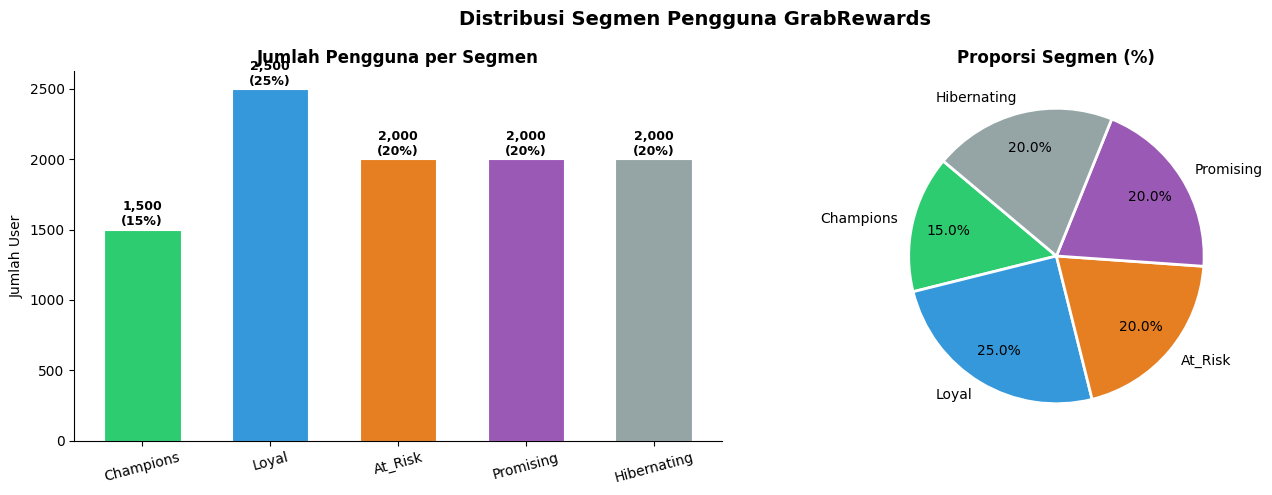

✓ Disimpan: eda_01_segment_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment distribution bar chart
seg_counts = df["segment_true"].value_counts().reindex(SEG_ORDER)
bar_colors = [COLORS[s] for s in SEG_ORDER]
bars = axes[0].bar(SEG_ORDER, seg_counts.values, color=bar_colors,
                   edgecolor="white", linewidth=0.8, width=0.6)
axes[0].set_title("Jumlah Pengguna per Segmen", fontweight="bold", fontsize=12)
axes[0].set_ylabel("Jumlah User")
axes[0].tick_params(axis="x", rotation=15)
for bar, val in zip(bars, seg_counts.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f"{val:,}\n({pct:.0f}%)",
                 ha="center", fontsize=9, fontweight="bold")

# Segment proportion pie chart
wedge_props = dict(edgecolor="white", linewidth=2)
axes[1].pie(seg_counts.values,
            labels=SEG_ORDER,
            autopct="%1.1f%%",
            colors=bar_colors,
            startangle=140,
            wedgeprops=wedge_props,
            pctdistance=0.75)
axes[1].set_title("Proporsi Segmen (%)", fontweight="bold", fontsize=12)

plt.suptitle("Distribusi Segmen Pengguna GrabRewards",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_01_segment_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Disimpan: eda_01_segment_distribution.png")

> * **Dominance of Highly Engaged Users:** The **Loyal** segment represents the largest group of users, accounting for **25% (2,500 users)** of the total population. When combined with the **Champions** segment (**15% or 1,500 users**), a solid **40% of the user base** consists of highly valuable and active core customers.
> * **Significant Churn Risk:** There is a critical retention warning as the **At_Risk** and **Hibernating** segments collectively make up **40% of the user base (2,000 users each)**. This indicates that a large portion of users are either drifting away or have completely stalled, signaling an urgent need for **re-engagement and win-back campaigns**.
> * **Balanced Growth Potential:** The **Promising** segment holds a steady **20% (2,000 users)**. These are newer or moderately active users who show potential, making them the perfect target for **targeted nurturing strategies** to convert them into Loyal or Champions.
> * **Evenly Distributed Segments:** Aside from the top two categories, the remaining user base is **perfectly evenly split (20% each)** among At_Risk, Promising, and Hibernating segments, reflecting a very structured yet split customer health profile.

## **3. Behavioral Profile per Segment (RFM)**

Each segment should have **different behavioral characteristics**: Champions are active and high spenders, while Hibernating ones haven't traded in a while. This section visually validates these differences.

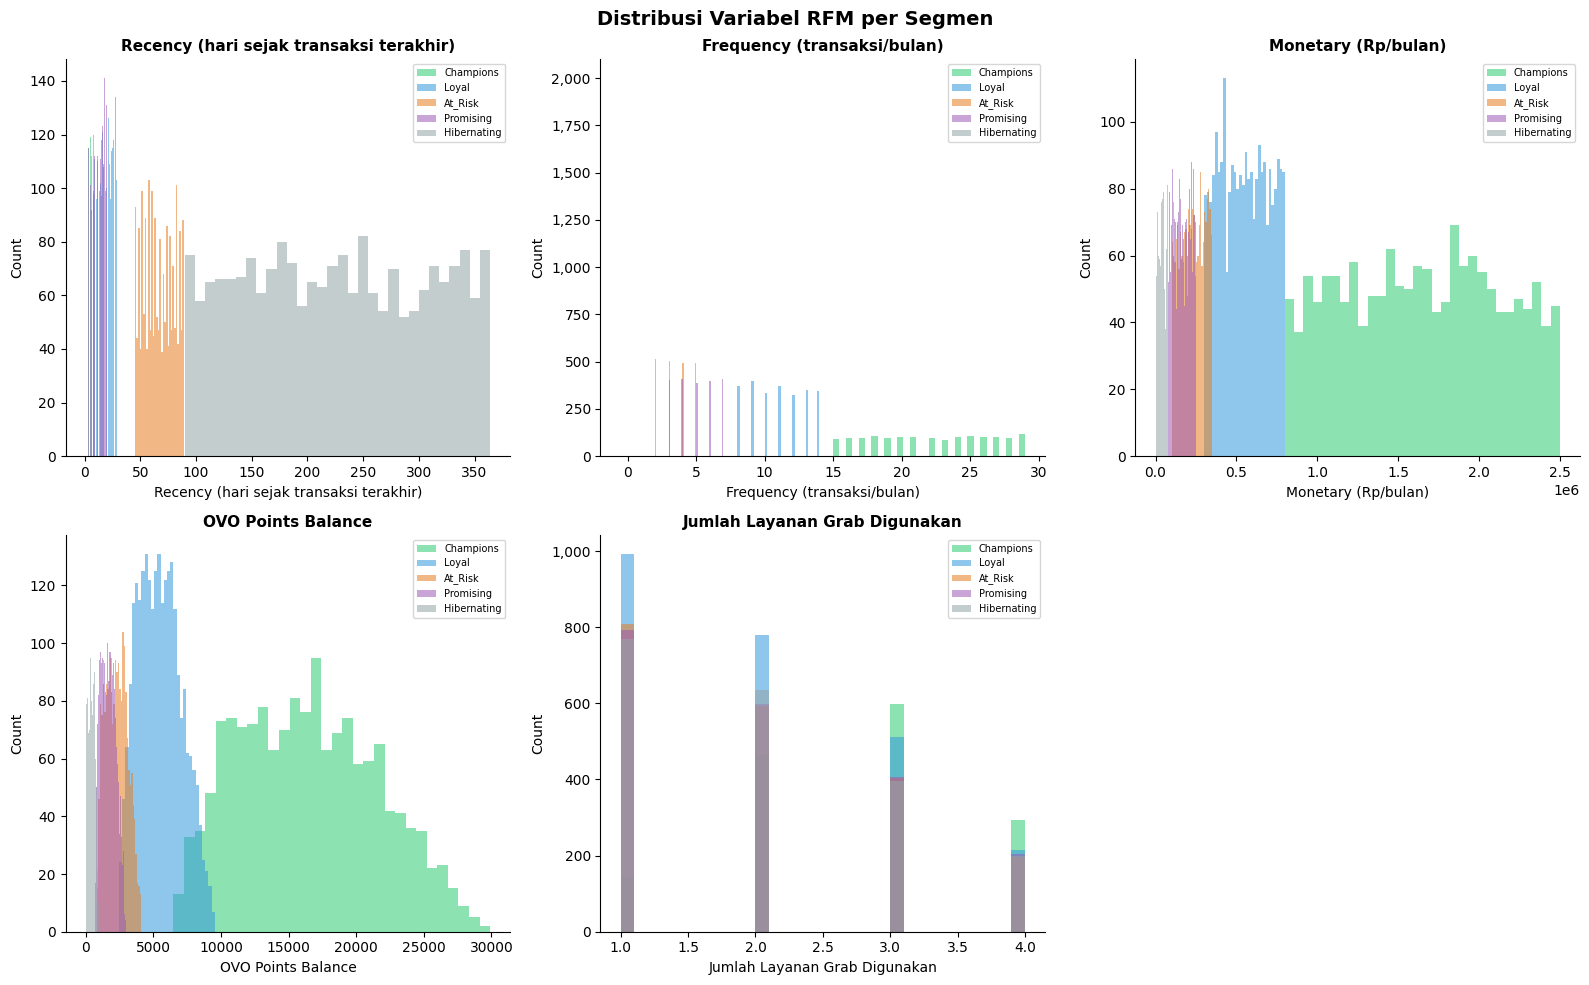

✓ Disimpan: eda_02_rfm_distributions.png


In [6]:
# ── Histogram overlapping per segmen ─────────────────────────
metrics = [
    ("recency_days",      "Recency (hari sejak transaksi terakhir)"),
    ("frequency_monthly", "Frequency (transaksi/bulan)"),
    ("monetary_monthly",  "Monetary (Rp/bulan)"),
    ("ovo_points_balance","OVO Points Balance"),
    ("n_services",        "Jumlah Layanan Grab Digunakan"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (col, label) in zip(axes[:5], metrics):
    for seg in SEG_ORDER:
        subset = df[df["segment_true"] == seg][col]
        ax.hist(subset, bins=30, alpha=0.55,
                label=seg, color=COLORS[seg], edgecolor="none")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend(fontsize=7, loc="upper right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{int(x):,}"))

axes[5].set_visible(False)

plt.suptitle("Distribusi Variabel RFM per Segmen",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_02_rfm_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Disimpan: eda_02_rfm_distributions.png")

> * **Distinct Recency Separation:** The user segments are clearly separated by their last transaction day (`Recency`). **Champions, Loyal, and Promising** users are highly active, clustering tightly within the **first 30 days**. Meanwhile, **At_Risk** users span from roughly **50 to 90 days**, and **Hibernating** users form a flat, prolonged distribution extending up to **360+ days**, indicating long-term inactivity.
> * **Champions Lead in Value and Frequency:** The **Champions** segment (green) clearly stands out as the most valuable group. They completely dominate the **highest frequency range (15 to 30 transactions/month)** and possess the **highest monetary spend (from 0.8 million up to 2.5 million Rp/month)**.
> * **OVO Points Balance Correlates with Loyalty:** There is a clear pattern where **Champions hold the highest OVO Points balance**, followed by Loyal users. This suggests that highly active users are successfully accumulating points, which can be leveraged as an incentive in **targeted loyalty reward programs** to prevent them from churning.
> * **Service Adoption is Concentrated:** Across the board, most users stick to using **1 to 3 Grab services** (`Jumlah Layanan Grab Digunakan`). Even for the highly valuable Loyal and Champions segments, adoption drops significantly at 4 services, indicating a strong opportunity for **cross-selling campaigns** to drive multi-service adoption among active users.

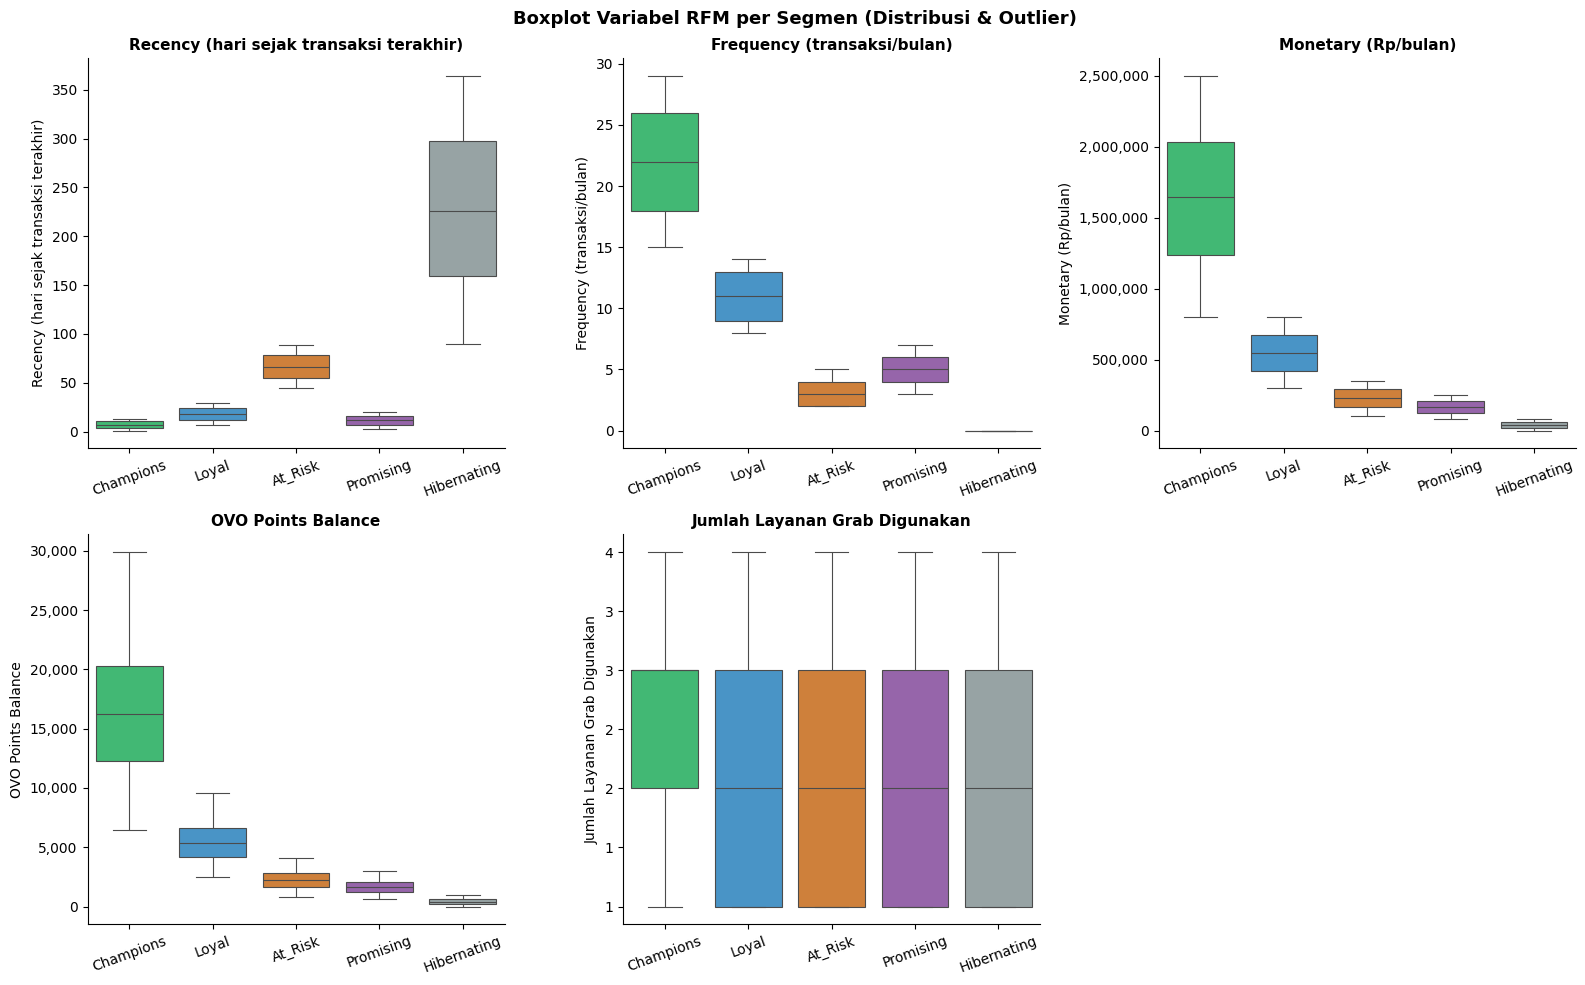

✓ Disimpan: eda_03_boxplot_per_segment.png


In [ ]:
# Boxplot per segment — outlier detection ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

flier_props = dict(marker=".", markersize=3, alpha=0.3)

for ax, (col, label) in zip(axes[:5], metrics):
    sns.boxplot(data=df, x="segment_true", y=col,
                order=SEG_ORDER,
                palette=COLORS,
                ax=ax,
                linewidth=0.8,
                flierprops=flier_props)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=20)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{int(x):,}"))

axes[5].set_visible(False)

plt.suptitle("Boxplot Variabel RFM per Segmen (Distribusi & Outlier)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_03_boxplot_per_segment.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Disimpan: eda_03_boxplot_per_segment.png")

> * **Champions are the Ultimate Value Drivers:** The **Champions** segment completely outperforms all others, maintaining the lowest recency (close to 0 days), the highest transaction frequency (**median around 22 transactions/month**), and by far the highest spending (**median around 1.6 million Rp/month**).
> * **Hibernating Users are Completely Stagnant:** The **Hibernating** segment shows extreme inactivity with a **median recency well over 200 days** (reaching up to 350+ days), combined with **near-zero frequency and monetary contribution**, indicating they have effectively churned.
> * **Promising vs. At_Risk Behavior:** While both segments share similar low-to-moderate frequency and monetary values, **Promising** users are much more recent (low recency), making them ideal for **growth nurturing**, whereas **At_Risk** users have passed the 50-day recency mark, making them critical targets for **immediate win-back campaigns**.
> * **OVO Points Heavily Concentrated in Top Tiers:** There is a stark, progressive drop in **OVO Points Balance** across the segments. **Champions hold a massive volume of points** (median over 15,000), while Loyal users follow second. The remaining three segments hold very negligible balances.
> * **Uniform Service Adoption Ceiling:** Interestingly, across almost all segments (Loyal down to Hibernating), the **median number of Grab services used is identical at 2**. Even Champions only push up to a median of 3, showing that **cross-selling remains a universal challenge** and opportunity regardless of user loyalty.

## **4. Distribution of Categorical Variables**

Looking at the distribution of **GrabRewards** tiers and **users'cities** to understand the demographic composition of the dataset.

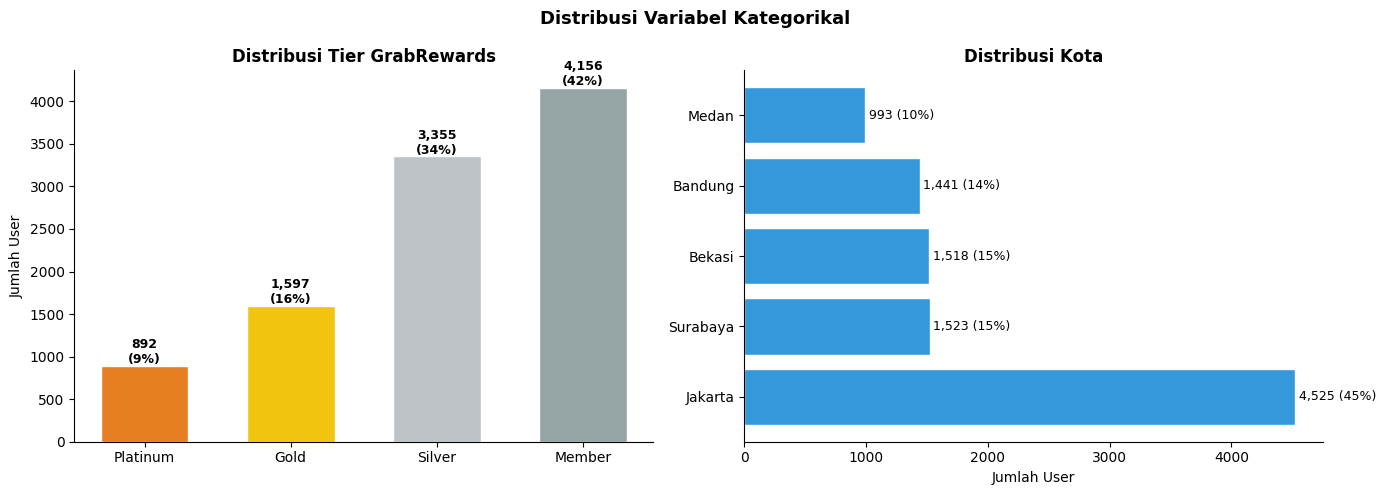

✓ Disimpan: eda_04_categorical_distributions.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi tier ───────────────────────────────────────────
tier_counts = df["tier"].value_counts().reindex(TIER_ORDER)
tier_colors = ["#E67E22", "#F1C40F", "#BDC3C7", "#95A5A6"]
bars = axes[0].bar(TIER_ORDER, tier_counts.values,
                   color=tier_colors, edgecolor="white", width=0.6)
axes[0].set_title("Distribusi Tier GrabRewards", fontweight="bold", fontsize=12)
axes[0].set_ylabel("Jumlah User")
for bar, val in zip(bars, tier_counts.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f"{val:,}\n({pct:.0f}%)",
                 ha="center", fontsize=9, fontweight="bold")

# Distribusi kota ───────────────────────────────────────────
city_counts = df["city"].value_counts()
bars2 = axes[1].barh(city_counts.index, city_counts.values,
                     color="#3498DB", edgecolor="white")
axes[1].set_title("Distribusi Kota", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Jumlah User")
for i, val in enumerate(city_counts.values):
    pct = val / len(df) * 100
    axes[1].text(val + 30, i,
                 f"{val:,} ({pct:.0f}%)",
                 va="center", fontsize=9)

plt.suptitle("Distribusi Variabel Kategorikal",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_04_categorical_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Disimpan: eda_04_categorical_distributions.png")

> * **Pyramid Structure in GrabRewards Tiers:** The user tier distribution follows a traditional pyramid, heavily dominated by baseline users. **Member (42%)** and **Silver (34%)** tiers collectively make up **76% of the user base**, while the elite tiers—**Gold (16%)** and **Platinum (9%)**—represent a much smaller, exclusive minority.
> * **Massive Jakarta Dominance:** In terms of geographical distribution, **Jakarta is the primary market leader**, accounting for a massive **45% of total users (4,525 users)**. This indicates that business activity and customer acquisition are highly centralized in the capital city.
> * **Secondary Cities are Closely Balanced:** Outside of Jakarta, the market is remarkably well-balanced among secondary cities. **Surabaya (15%), Bekasi (15%), and Bandung (14%)** exhibit almost identical user volumes, making them steady secondary hubs, while **Medan lags slightly behind at 10%**.
> * **Opportunity for Tier Upgrades:** With over three-quarters of the population sitting in Member or Silver tiers, there is a substantial opportunity for **gamification and targeted promotional campaigns** to encourage these entry-level users to step up to higher-value tiers.

## **5️. Churn Analysis**

The most important part in this EDA, **who is most at risk of churn?** Analyze from 3 angles: segment, tier, and city.

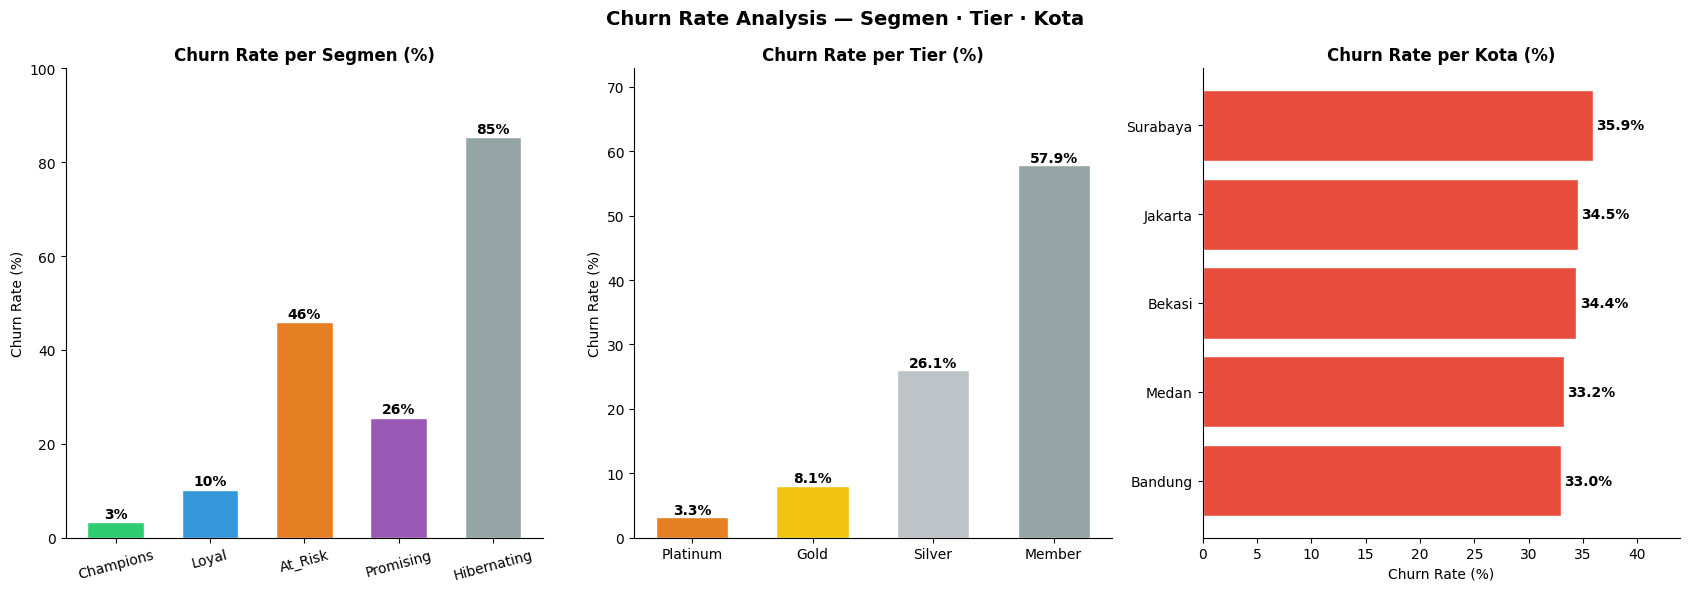

✓ Disimpan: eda_05_churn_rate_analysis.png


In [9]:
# ── Churn rate per segmen ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

churn_seg = (df.groupby("segment_true")["churn_label"]
               .mean()
               .reindex(SEG_ORDER) * 100)

bars = axes[0].bar(SEG_ORDER,
                   churn_seg.values,
                   color=[COLORS[s] for s in SEG_ORDER],
                   edgecolor="white", width=0.6)
axes[0].set_title("Churn Rate per Segmen (%)", fontweight="bold", fontsize=12)
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=15)
for bar, val in zip(bars, churn_seg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f"{val:.0f}%",
                 ha="center", fontsize=10, fontweight="bold")

# ── Churn rate per tier ───────────────────────────────────────
churn_tier = (df.groupby("tier")["churn_label"]
                .mean()
                .reindex(TIER_ORDER) * 100)
tier_colors = ["#E67E22", "#F1C40F", "#BDC3C7", "#95A5A6"]
bars2 = axes[1].bar(TIER_ORDER, churn_tier.values,
                    color=tier_colors, edgecolor="white", width=0.6)
axes[1].set_title("Churn Rate per Tier (%)", fontweight="bold", fontsize=12)
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_ylim(0, churn_tier.max() + 15)
for bar, val in zip(bars2, churn_tier.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{val:.1f}%",
                 ha="center", fontsize=10, fontweight="bold")

# ── Churn rate per kota ───────────────────────────────────────
churn_city = (df.groupby("city")["churn_label"]
                .mean()
                .sort_values(ascending=True) * 100)
bars3 = axes[2].barh(churn_city.index, churn_city.values,
                     color="#E74C3C", edgecolor="white")
axes[2].set_title("Churn Rate per Kota (%)", fontweight="bold", fontsize=12)
axes[2].set_xlabel("Churn Rate (%)")
axes[2].set_xlim(0, churn_city.max() + 8)
for i, val in enumerate(churn_city.values):
    axes[2].text(val + 0.3, i, f"{val:.1f}%",
                 va="center", fontsize=10, fontweight="bold")

plt.suptitle("Churn Rate Analysis — Segmen · Tier · Kota",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_05_churn_rate_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Disimpan: eda_05_churn_rate_analysis.png")

> * **Alarming Churn in Latent Segments:** The **Hibernating** segment exhibits an extremely critical **85% churn rate**, followed by the **At_Risk** segment at **46%**. This confirms that immediate, aggressive win-back campaigns are needed for these specific user groups before they completely leave the ecosystem.
> * **Strong Loyalty Retention:** On the flip side, user retention strategies are highly effective for core groups, with **Champions** maintaining an outstandingly low **3% churn rate** and **Loyal** users at just **10%**.
> * **Inverse Relationship Between Tier and Churn:** There is a clear trend showing that higher tiers retain users much better. **Members** have the highest attrition at **57.9%**, while **Platinum** users are incredibly sticky with a minimal **3.3% churn rate**. This highlights the importance of pushing entry-level users to level up their membership tiers.
> * **Consistent Churn Across Cities:** Geographically, the churn rate is remarkably uniform across all regions, hovering tightly between **33.0% (Bandung)** and **35.9% (Surabaya)**. This indicates that churn is driven by macro product-wide factors or user behavioral cycles rather than localized regional issues.

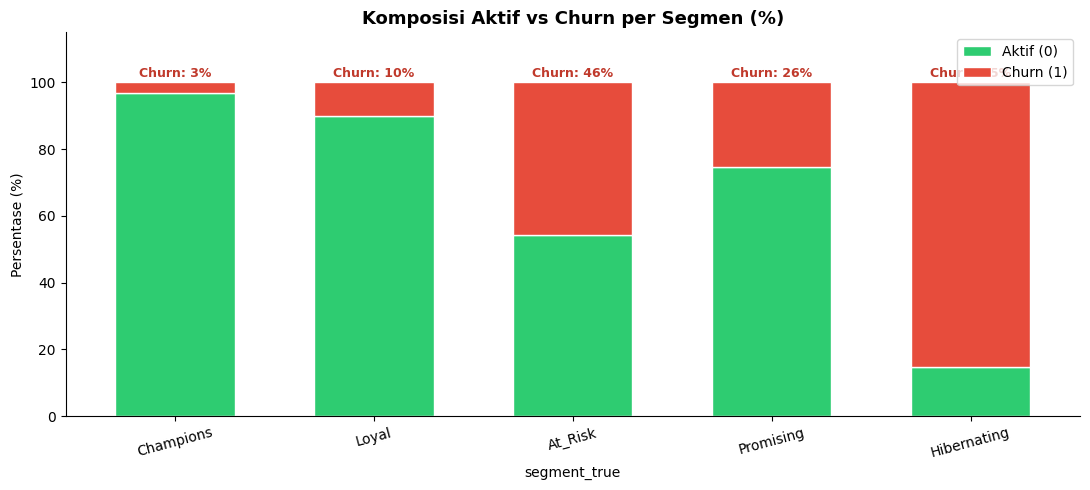

✓ Disimpan: eda_06_churn_composition.png


In [ ]:
# ── Stacked bar: komposisi churn vs aktif per segmen ─────────
churn_comp = df.groupby("segment_true")["churn_label"].value_counts(
    normalize=True).mul(100).unstack().reindex(SEG_ORDER)
churn_comp.columns = ["Aktif (0)", "Churn (1)"]

fig, ax = plt.subplots(figsize=(11, 5))
churn_comp.plot(kind="bar", stacked=True, ax=ax,
                color=["#2ECC71", "#E74C3C"],
                edgecolor="white", width=0.6)
ax.set_title("Komposisi Aktif vs Churn per Segmen (%)",
             fontweight="bold", fontsize=13)
ax.set_ylabel("Persentase (%)")
ax.set_ylim(0, 115)
ax.tick_params(axis="x", rotation=15)
ax.legend(loc="upper right", fontsize=10)

for i, seg in enumerate(SEG_ORDER):
    churn_val = churn_comp.loc[seg, "Churn (1)"]
    aktif_val = churn_comp.loc[seg, "Aktif (0)"]
    ax.text(i, aktif_val + churn_val + 1.5,
            f"Churn: {churn_val:.0f}%",
            ha="center", fontsize=9, fontweight="bold", color="#C0392B")

plt.tight_layout()
plt.savefig("../outputs/figures/eda_06_churn_composition.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Disimpan: eda_06_churn_composition.png")

> * **Extreme Attrition in the Hibernating Segment:** The **Hibernating** group represents the most critical area of concern, with an overwhelming **85% churn rate** (leaving only 15% active). This indicates that users in this category have almost entirely abandoned the platform.
> * **High Vulnerability of At_Risk Users:** Nearly half of the **At_Risk** segment has already churned, sitting at a **46% churn rate**. This highlights a crucial window of opportunity where **immediate proactive intervention** is required before the remaining 54% active users slide into the hibernating phase.
> * **Solid Retention Among Core Segments:** The platform successfully retains its most valuable users. The **Champions** segment shows an exceptional **97% active rate** (only 3% churn), while the **Loyal** segment maintains a strong **90% active rate** (10% churn).
> * **Promising Segment Shows Healthy Potential:** The **Promising** user base remains mostly healthy, with **74% of its users staying active** and a manageable **26% churn rate**. This segment serves as a great target for engagement campaigns to prevent further attrition and push them toward becoming loyal customers.

## **6. Correlation Between Variables**

Looking at the **linear relationship** between numeric variables, specifically which variables are most correlated with `churn_label`. This serves as an initial preview before diving into the feature importance model.

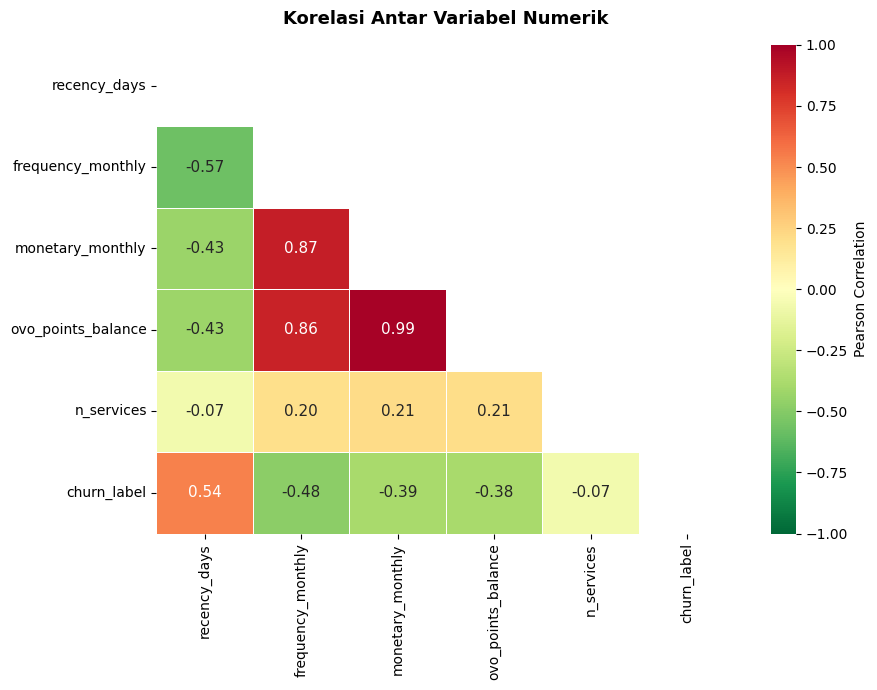

✓ Disimpan: eda_07_correlation_heatmap.png


In [11]:
numeric_cols = ["recency_days", "frequency_monthly", "monetary_monthly",
                "ovo_points_balance", "n_services", "churn_label"]

corr = df[numeric_cols].corr()

# ── Heatmap ───────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,
            annot=True, fmt=".2f",
            cmap="RdYlGn_r",
            mask=mask,
            vmin=-1, vmax=1,
            linewidths=0.5,
            annot_kws={"size": 11},
            cbar_kws={"label": "Pearson Correlation"})
plt.title("Korelasi Antar Variabel Numerik",
          fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("../outputs/figures/eda_07_correlation_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Disimpan: eda_07_correlation_heatmap.png")

> * **Direct Spend-to-Points Link:** A near-perfect positive correlation of **0.99** shows that `ovo_points_balance` is **directly driven by `monetary_monthly**` spend.
> * **High Frequency Means High Spend:** The strong **0.87** correlation between `frequency_monthly` and `monetary_monthly` proves that **frequent users generate the most revenue**.
> * **Recency Drives Churn:** With a **0.54** positive correlation, `recency_days` is the **strongest indicator of churn risk**; longer gaps between transactions mean a higher likelihood of leaving.
> * **Activity Prevents Attrition:** The strong negative correlation (**-0.48**) between `frequency_monthly` and `churn_label` confirms that **consistent engagement effectively lowers churn**.
> * **Cross-Selling Has Low Impact:** The weak correlation (**-0.07**) for `n_services` indicates that the **number of services used barely influences churn** compared to frequency and spending habits.

In [12]:
# Top korelasi dengan churn_label
print("Korelasi dengan churn_label (diurutkan):")
print("-" * 45)
churn_corr = (corr["churn_label"]
              .drop("churn_label")
              .sort_values(key=abs, ascending=False))
for col, val in churn_corr.items():
    direction = "↑ positif" if val > 0 else "↓ negatif"
    bar = "█" * int(abs(val) * 20)
    print(f"  {col:<25} {val:+.3f}  {bar}  ({direction})")

Korelasi dengan churn_label (diurutkan):
---------------------------------------------
  recency_days              +0.539  ██████████  (↑ positif)
  frequency_monthly         -0.483  █████████  (↓ negatif)
  monetary_monthly          -0.386  ███████  (↓ negatif)
  ovo_points_balance        -0.383  ███████  (↓ negatif)
  n_services                -0.068  █  (↓ negatif)


> * **Inactivity is the Top Churn Predictor:** `recency_days` has the strongest correlation (**+0.539**). This positive value confirms that **the more days pass since a user's last transaction, the higher their risk of churning**.
> * **Transaction Frequency Inversely Fights Churn:** `frequency_monthly` has the strongest negative correlation (**-0.483**), proving that **regular transactional activity is the most effective factor in preventing user churn**.
> * **High Value and Loyalty Points Help Retention:** Both `monetary_monthly` (**-0.386**) and `ovo_points_balance` (**-0.383**) show notable negative correlations. This means **high-spending users and those holding larger point balances are less likely to leave**.
> * **Number of Services Played Minimal Role:** `n_services` shows a negligible negative correlation of just **-0.068**, indicating that **simply using more features or services has almost no impact on whether a user decides to churn**.

## **7. Summary Statistics Table per Segment**

This table summarizes the numerical profile of each segment in one view, useful for the **methodology and findings** section of the final report.

In [13]:
seg_stats = df.groupby("segment_true").agg(
    n_users        = ("user_id",           "count"),
    avg_recency    = ("recency_days",       "mean"),
    avg_frequency  = ("frequency_monthly",  "mean"),
    avg_monetary   = ("monetary_monthly",   "mean"),
    avg_ovo_pts    = ("ovo_points_balance", "mean"),
    avg_n_services = ("n_services",         "mean"),
    churn_rate     = ("churn_label",        "mean"),
).round(2).reindex(SEG_ORDER)

# Format tampilan
seg_display = seg_stats.copy()
seg_display["churn_rate"]   = (seg_display["churn_rate"] * 100
                                ).round(1).astype(str) + "%"
seg_display["avg_monetary"] = seg_display["avg_monetary"].apply(
    lambda x: f"Rp {x:,.0f}")
seg_display["n_users"]      = seg_display["n_users"].apply(
    lambda x: f"{x:,}")
seg_display.index.name = "Segmen"
seg_display.columns    = ["N Users", "Avg Recency", "Avg Freq/bln",
                           "Avg Monetary", "Avg OVO Pts",
                           "Avg Services", "Churn Rate"]

print("Statistik Ringkasan per Segmen:")
display(seg_display)

Statistik Ringkasan per Segmen:


,N Users,Avg Recency,Avg Freq/bln,Avg Monetary,Avg OVO Pts,Avg Services,Churn Rate
Segmen,,,,,,,
Champions,"1,500",7.10,22.15,"Rp 1,646,495",16441.13,2.69,3.0%
Loyal,"2,500",18.26,10.93,"Rp 549,638",5493.34,1.98,10.0%
At_Risk,"2,000",66.69,3.48,"Rp 227,739",2273.84,1.99,46.0%
Promising,"2,000",11.73,5.00,"Rp 165,935",1657.34,2.01,26.0%
Hibernating,"2,000",226.70,0.00,"Rp 40,460",405.36,2.01,85.0%


> * **Champions Dominate Value:** The **Champions** segment drives maximum platform value, transacting **22.15 times/month** with a massive **Rp 1.6M+ average spend** and a tiny **3% churn rate**.
> * **Hibernating Users are Dead Weight:** The **Hibating** group is functionally lost, averaging **226.70 days of inactivity**, **0.00 transactions**, and a critical **85% churn rate**.
> * **Promising Tier is Ripe for Growth:** With a low average recency of **11.73 days**, **Promising** users are highly active but low-spending (**Rp 165K**), making them ideal targets for **upselling campaigns**.
> * **At_Risk Needs Immediate Rescue:** The **At_Risk** segment faces a steep **46% churn rate** as their inactivity climbs to an average of **66.69 days**, requiring **urgent win-back interventions**.
> * **Universal Service Bottleneck:** Across all five segments, the **average number of services used stays flat between 1.98 and 2.69**, highlighting a universal barrier to **cross-selling**.

## **8. Summary & Key Insight**

A summary of EDA findings that will form the foundation of analysis in the next notebook.

In [14]:
# ── Revenue at risk preview ───────────────────────────────────
seg_stats_raw = df.groupby("segment_true").agg(
    n_users      = ("user_id",          "count"),
    avg_monetary = ("monetary_monthly", "mean"),
    churn_rate   = ("churn_label",      "mean"),
).reindex(SEG_ORDER)

seg_stats_raw["revenue_at_risk"] = (
    seg_stats_raw["n_users"] *
    seg_stats_raw["avg_monetary"] *
    seg_stats_raw["churn_rate"]
).round(-3)

total_risk = seg_stats_raw["revenue_at_risk"].sum()

print("=" * 60)
print("  PREVIEW REVENUE AT RISK PER SEGMEN")
print("=" * 60)
print(f"  {'Segmen':<14} {'N Users':>7}  {'Churn%':>8}  {'Revenue at Risk':>16}")
print("-" * 60)
for seg, row in seg_stats_raw.iterrows():
    print(f"  {seg:<14} {row.n_users:>7,}  "
          f"{row.churn_rate:>7.0%}  "
          f"Rp {row.revenue_at_risk:>12,.0f}")
print("-" * 60)
print(f"  {'TOTAL':<14} {'':>7}  {'':>8}  Rp {total_risk:>12,.0f}")
print(f"\n  → Rp {total_risk/1_000_000:.0f} juta/bulan total revenue at risk")

  PREVIEW REVENUE AT RISK PER SEGMEN
  Segmen         N Users    Churn%   Revenue at Risk
------------------------------------------------------------
  Champions      1,500.0       3%  Rp   80,678,000
  Loyal          2,500.0      10%  Rp  140,158,000
  At_Risk        2,000.0      46%  Rp  208,837,000
  Promising      2,000.0      26%  Rp   84,627,000
  Hibernating    2,000.0      85%  Rp   69,024,000
------------------------------------------------------------
  TOTAL                             Rp  583,324,000

  → Rp 583 juta/bulan total revenue at risk


> * **Highest Financial Threat from At_Risk Users:** The **At_Risk** segment presents the single largest threat to business income, carrying a massive **Rp 208,837,000 revenue at risk** due to a high **46% churn rate**.
> * **Substantial Threat from Core Customers:** Even though their churn percentages are low, the combined revenue at risk from **Champions and Loyal** segments is a staggering **Rp 220,836,000**, meaning retaining these core high-spenders must remain a top priority.
> * **Diminishing Returns from Hibernating Users:** Despite having the highest churn velocity at **85%**, the **Hibernating** segment accounts for the **lowest financial risk (Rp 69,024,000)**, confirming they have already bottomed out in transactional value.
> * **Massive Total Loss Exposure:** The overall business faces an alarming **Rp 583,324,000 total revenue at risk per month**, emphasizing an immediate need for an ecosystem-wide, targeted customer retention framework.

In [ ]:
print("  Figures tersimpan di outputs/figures/:")
figures = [
    "eda_01_segment_distribution.png",
    "eda_02_rfm_distributions.png",
    "eda_03_boxplot_per_segment.png",
    "eda_04_categorical_distributions.png",
    "eda_05_churn_rate_analysis.png",
    "eda_06_churn_composition.png",
    "eda_07_correlation_heatmap.png",
]
for f in figures:
    print(f"    ✓ {f}")
print()
print("  ➜ Lanjut ke: 03_rfm_segmentation.ipynb")


  SUMMARY — EDA SELESAI

  Dataset:
    Shape      : 10,000 rows × 12 cols
    Duplikat   : 0
    Missing    : 0
    Churn rate : 34.4%

  5 Insight Kunci:
    1. Hibernating churn rate 85% — mayoritas sudah tidak aktif
    2. At_Risk (20% users) = revenue at risk terbesar per bulan
    3. Champions hanya 4% churn — multi-service = kunci retensi
    4. recency_days = korelasi terkuat dengan churn (+positif)
    5. n_services = sinyal loyalitas paling konsisten antar segmen

  Figures tersimpan di outputs/figures/:
    ✓ eda_01_segment_distribution.png
    ✓ eda_02_rfm_distributions.png
    ✓ eda_03_boxplot_per_segment.png
    ✓ eda_04_categorical_distributions.png
    ✓ eda_05_churn_rate_analysis.png
    ✓ eda_06_churn_composition.png
    ✓ eda_07_correlation_heatmap.png

  ➜ Lanjut ke: 03_rfm_segmentation.ipynb
